In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
xtrain.shape

(60000, 28, 28)

In [4]:
xtest.shape

(10000, 28, 28)

In [5]:
xtrain[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
xtrain[0].shape

(28, 28)

In [7]:
ytrain

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

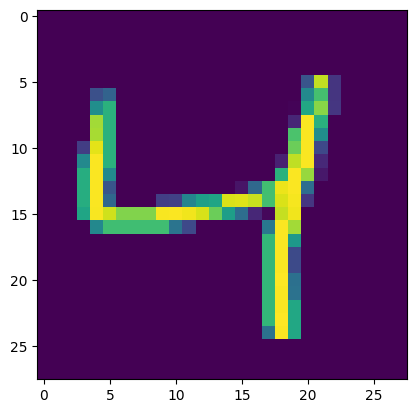

In [8]:
plt.imshow(xtrain[2])

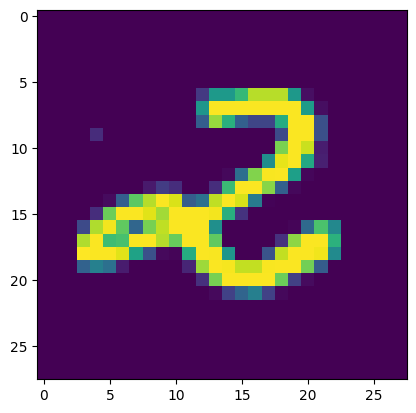

In [9]:
plt.imshow(xtrain[5647])

In [10]:
xtrain = xtrain/255
xtest = xtest/255

In [11]:
xtrain[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [12]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28))) # Flatten Layer
model.add(Dense(128, activation='relu'))  # Hidden Layer
model.add(Dense(32, activation='relu'))   # Hidden Layer
model.add(Dense(10, activation='sigmoid')) #Output Layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [15]:
history = model.fit(xtrain, ytrain, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9189 - loss: 0.2787 - val_accuracy: 0.9561 - val_loss: 0.1506
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9647 - loss: 0.1180 - val_accuracy: 0.9680 - val_loss: 0.1097
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9744 - loss: 0.0813 - val_accuracy: 0.9684 - val_loss: 0.1025
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9808 - loss: 0.0599 - val_accuracy: 0.9706 - val_loss: 0.0946
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9855 - loss: 0.0462 - val_accuracy: 0.9703 - val_loss: 0.1084
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0396 - val_accuracy: 0.9724 - val_loss: 0.0992
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9904 - loss: 0.0290 - val_accuracy: 0.9758 - val_loss: 0.0917
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9910 - loss: 0.0264 - 

In [16]:
y_prob = model.predict(xtest)
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.8726660e-06, 1.8583146e-03, 1.6130587e-02, ..., 1.0000000e+00,
        5.7300954e-06, 1.2414684e-01],
       [1.3214489e-03, 3.8731492e-01, 1.0000000e+00, ..., 1.9949663e-07,
        7.7255923e-01, 5.8333106e-14],
       [1.1086704e-06, 1.0000000e+00, 1.2176422e-01, ..., 7.1050358e-01,
        7.3184490e-01, 7.8511048e-06],
       ...,
       [1.7298714e-13, 8.5587728e-01, 1.5947148e-13, ..., 4.8686489e-01,
        5.7162285e-01, 3.7864736e-01],
       [3.3604297e-06, 2.7944670e-05, 4.1238289e-12, ..., 4.7776024e-07,
        9.8992002e-01, 4.6522561e-10],
       [2.6661630e-03, 2.1488632e-10, 4.7691460e-03, ..., 4.9375899e-09,
        7.5197093e-02, 2.2266052e-07]], dtype=float32)

In [17]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [18]:
accuracy_score(ytest, y_pred)

0.9724

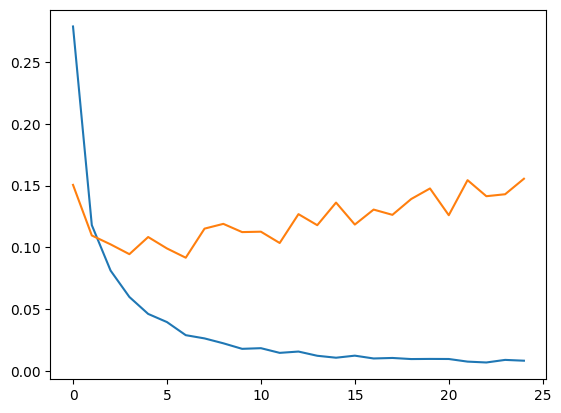

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

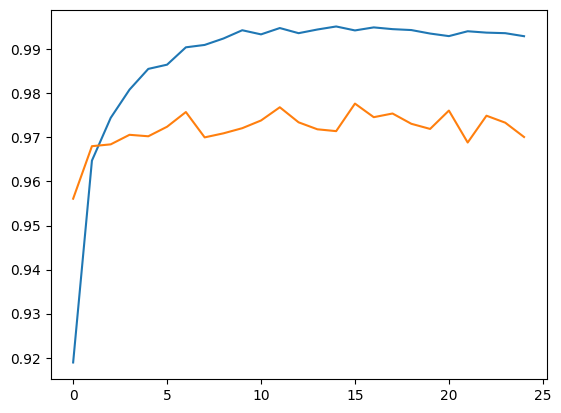

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

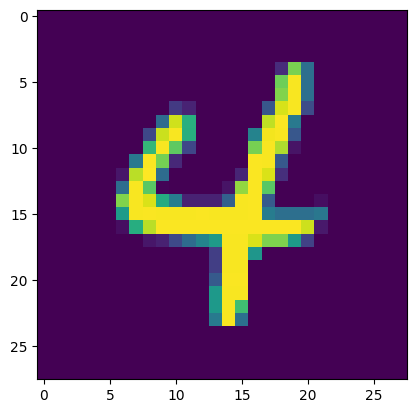

In [29]:
plt.imshow(xtest[8797])

In [30]:
model.predict(xtest[8797].reshape(1, 28, 28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[6.3551728e-09, 9.2435545e-01, 3.8152205e-08, 1.6285835e-08,
        1.0000000e+00, 4.5435353e-09, 1.6175510e-07, 6.7566967e-01,
        7.6869178e-08, 9.8257908e-05]], dtype=float32)

In [31]:
model.predict(xtest[8797].reshape(1, 28, 28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([4])